## Эксперименты, выбор и сохранение модели


Этот ноутбук продолжает `01_eda_preprocessing_baseline.ipynb`.

EDA, подготовка данных и исходный baseline выполнены в первом ноутбуке. 
Здесь используются уже подготовленные `train.csv` и `test.csv` и решаются следующие задачи: сравнение моделей, выбор лучшей конфигурации, финальная проверка на test и сохранение модели.

## 1. Подготовка окружения

In [1]:
from pathlib import Path
import sys
import joblib
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if not (ROOT / "train_model.py").exists():
    ROOT = ROOT.parent
if not (ROOT / "train_model.py").exists():
    raise FileNotFoundError("Открой в VS Code папку проекта с train_model.py и data/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from train_model import (
    LABEL_NAMES, load_data, make_candidates, run_experiments,
    choose_and_fit, evaluate_test, save_and_check,
    save_figures, write_report, write_json,
)
REPORTS = ROOT / "reports" / "experiments"
REPORTS.mkdir(parents=True, exist_ok=True)

## 2. Загрузка и проверка данных
`text` содержит обращение, `label` - правильную категорию.

При загрузке проверяются пропуски, пустые строки, категории и повторяющиеся тексты.
Проверка совпадений использует нижний регистр и удаление лишних пробелов.

In [2]:
train, test, groups, clean_test_mask, audit = load_data(ROOT)
write_json(REPORTS / "data_audit.json", audit)
print(f"Train: {len(train)} обращений; test: {len(test)}; классов: {train.label.nunique()}")
display(train.head())
display(pd.DataFrame(LABEL_NAMES.items(), columns=["label", "пояснение"]))

Train: 764 обращений; test: 191; классов: 8


,text,label
0,адрес подтверждения не приняли квитанция читае...,KYC_VERIFICATION
1,"Слишком много попыток, блок на сутки. Можно ли...",APP_LOGIN
2,СМС с кодом входа приходит с задержкой 10–15 м...,APP_LOGIN
3,SEPA перевод CHF отправлен банк говорит ждите ...,INCOMING_DELAY
4,возврат авиабилета обещали до 7 дней прошло 9 ...,INCOMING_DELAY


,label,пояснение
0,ACCOUNT_SEIZED,Ограничения и блокировка счёта
1,APP_LOGIN,Проблемы со входом
2,APP_TECH,Технические проблемы приложения
3,CARD_ISSUE,Проблемы с картой
4,FRAUD_SUSPECTED,Подозрение на мошенничество
5,INCOMING_DELAY,Задержка входящего платежа
6,KYC_VERIFICATION,Проверка личности и документов
7,PAYMENT_OUT_FAIL,Проблемы с исходящим платежом


In [3]:
print("Точные дубликаты внутри train:", audit["train_exact_duplicates"])
print("Повторы внутри train после нормализации:", audit["train_normalized_duplicates"])
print("Строки test, совпадающие с train после нормализации:", audit["normalized_overlap_test_rows"])
print("Test без совпадений с train:", audit["primary_test_rows"])
print("Исходные CSV остаются без изменений.")

Точные дубликаты внутри train: 0
Повторы внутри train после нормализации: 2
Строки test, совпадающие с train после нормализации: 1
Test без совпадений с train: 190
Исходные CSV остаются без изменений.


### Обоснование использования групповых разбиений

В `train` обнаружены два обращения, совпадающие после приведения текста к нижнему регистру и удаления лишних пробелов. 
`StratifiedGroupKFold` не допускает попадания одинаковых нормализованных текстов одновременно в обучение и валидацию и при этом стремится сохранить близкое распределение классов между folds. 
Все модели проверяются на одинаковых пяти разбиениях с `random_state=42`.

Одно совпадение между `test` и `train` исключается из основной итоговой метрики.

## 3. Задаем три эксперимента

| Вариант | Признаки | Модель | Что проверяем |
|---|---|---|---|
| Baseline | Отдельные слова | LogisticRegression | Исходный уровень |
| Эксперимент 1 | Слова и пары соседних слов | LogisticRegression | Добавление контекста |
| Эксперимент 2 | Слова и пары соседних слов | LinearSVC | Смена классификатора относительно эксперимента 1 |
| Эксперимент 3 | Фрагменты слов длиной 3–5 символов (`char_wb`) | LinearSVC | Смена признаков относительно эксперимента 2 |

Параметры моделей заданы заранее и не подбираются по тестовой выборке.

In [4]:
candidates = make_candidates()
for name, pipeline in candidates.items():
    print(name)
    print(pipeline)
    print()

baseline_word_lr
Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

exp1_word_bigrams_lr
Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

exp2_word_bigrams_svc
Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier', LinearSVC(max_iter=5000, random_state=42))])

exp3_char_svc
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))),
                ('classifier', LinearSVC(max_iter=5000, random_state=42))])



## 4. Кросс-валидация

Для каждого варианта проводим кросс-валидацию из пяти разбиений. TF-IDF обучается отдельно внутри каждого разбиения. `results` содержит итоговые метрики, а `oof` - прогнозы для строк, которые модель не видела при обучении.

Считаем Accuracy, Precision-macro, Recall-macro и F1-macro. Основной критерий выбора - **средний F1-macro**, который даёт каждой категории одинаковый вес.

In [5]:
results, oof = run_experiments(train, groups, candidates, REPORTS)
columns = ["model", "accuracy_mean", "precision_macro_mean", "recall_macro_mean", "f1_macro_mean", "f1_macro_std"]
display(results[columns].round(4))
print("Подробные метрики по разбиениям: reports/experiments/fold_metrics.csv")

Завершено: baseline_word_lr
Завершено: exp1_word_bigrams_lr
Завершено: exp2_word_bigrams_svc
Завершено: exp3_char_svc


,model,accuracy_mean,precision_macro_mean,recall_macro_mean,f1_macro_mean,f1_macro_std
0,exp3_char_svc,0.9529,0.9536,0.9496,0.9505,0.0138
1,exp2_word_bigrams_svc,0.9332,0.9398,0.9290,0.9311,0.0261
2,baseline_word_lr,0.9070,0.9165,0.9017,0.9043,0.0305
3,exp1_word_bigrams_lr,0.9083,0.9183,0.9012,0.9042,0.0374


Подробные метрики по разбиениям: reports/experiments/fold_metrics.csv


### Вывод по экспериментам

Добавление словесных биграмм к Logistic Regression практически не изменило качество: F1-macro изменился с **0.9043 до 0.9042**.
Замена Logistic Regression на `LinearSVC` при тех же словесных признаках повысила F1-macro до **0.9311** - на **2.69 п.п.** относительно эксперимента 1.
Переход к символьным признакам `char_wb` дополнительно повысил F1-macro до **0.9505** - ещё на **1.94 п.п.** относительно эксперимента 2 и на **4.62 п.п.** относительно baseline.
У `exp3_char_svc` также наименьший разброс F1-macro между folds (`std = 0.0138`).

## 5. Выбор и обучение модели

Выбрана модель `exp3_char_svc`, поскольку она показала наибольший средний F1-macro по результатам кросс-валидации (CV)- 0,9505. Выбор выполняется только на `train`; при равенстве учитывается меньший `std`, затем имя модели. После выбора модель обучается на всех 764 строках `train`. Решение сохраняется в `selection.json` до оценки на `test`.

In [6]:
best_name, model = choose_and_fit(results, candidates, train, REPORTS)
best_row = results.set_index("model").loc[best_name]
base_row = results.set_index("model").loc["baseline_word_lr"]
print("Выбранная модель:", best_name)
print(f"F1-macro CV: {best_row.f1_macro_mean:.4f} ± {best_row.f1_macro_std:.4f}")
print(f"Baseline на тех же разбиениях: {base_row.f1_macro_mean:.4f}")
print(f"Разница: {(best_row.f1_macro_mean - base_row.f1_macro_mean) * 100:+.2f} процентного пункта")

Выбрана и обучена на всём train: exp3_char_svc
Выбранная модель: exp3_char_svc
F1-macro CV: 0.9505 ± 0.0138
Baseline на тех же разбиениях: 0.9043
Разница: +4.62 процентного пункта


### Проверка сложного класса APP_TECH на OOF-прогнозах

Проверяется, как baseline и выбранная модель справились с APP_TECH на общих разбиениях.

In [7]:
from sklearn.metrics import classification_report
rows = []
for name in ["baseline_word_lr", best_name]:
    per_class = classification_report(train.label, oof[name], output_dict=True, zero_division=0)
    rows.append({"model": name, **per_class["APP_TECH"]})
display(pd.DataFrame(rows).round(4))

,model,precision,recall,f1-score,support
0,baseline_word_lr,0.9194,0.7703,0.8382,74.0
1,exp3_char_svc,0.9254,0.8378,0.8794,74.0


### Вывод

Для `APP_TECH` выбранная модель улучшила Recall с **0.7703 до 0.8378**, а F1 - с **0.8382 до 0.8794**.
То есть модель стала находить больше технических проблем приложения, сохранив высокую Precision.

## 6. Финальная проверка на test

После выбора проверяем модель на test. Основную метрику считаем на 190 строках без совпадений с train; дополнительно показываем результат на всех 191 строках. Остальные модели на test не сравниваем.

In [8]:
test_pred, test_summary, class_report, matrix = evaluate_test(
    model, test, clean_test_mask, REPORTS
)
display(pd.DataFrame(test_summary[key] for key in [
    "primary_test_without_train_duplicates", "original_test_all_rows"
]).set_axis(["Test без совпадений с train", "Исходный test целиком"]).round(4))
display(pd.DataFrame(class_report).T.loc[sorted(LABEL_NAMES)].round(4))

Итоговые метрики без повторов train: {"accuracy": 0.9473684210526315, "precision_macro": 0.9509152421652421, "recall_macro": 0.9431014328808447, "f1_macro": 0.9449919756750492}


,n,accuracy,precision_macro,recall_macro,f1_macro
Test без совпадений с train,190,0.9474,0.9509,0.9431,0.9450
Исходный test целиком,191,0.9476,0.9509,0.9443,0.9457


,precision,recall,f1-score,support
ACCOUNT_SEIZED,0.9167,0.9167,0.9167,24.0
APP_LOGIN,0.9630,1.0000,0.9811,26.0
APP_TECH,1.0000,0.8235,0.9032,17.0
CARD_ISSUE,1.0000,0.9200,0.9583,25.0
FRAUD_SUSPECTED,0.9200,1.0000,0.9583,23.0
INCOMING_DELAY,1.0000,0.9615,0.9804,26.0
KYC_VERIFICATION,0.8846,1.0000,0.9388,23.0
PAYMENT_OUT_FAIL,0.9231,0.9231,0.9231,26.0


### Графики результатов

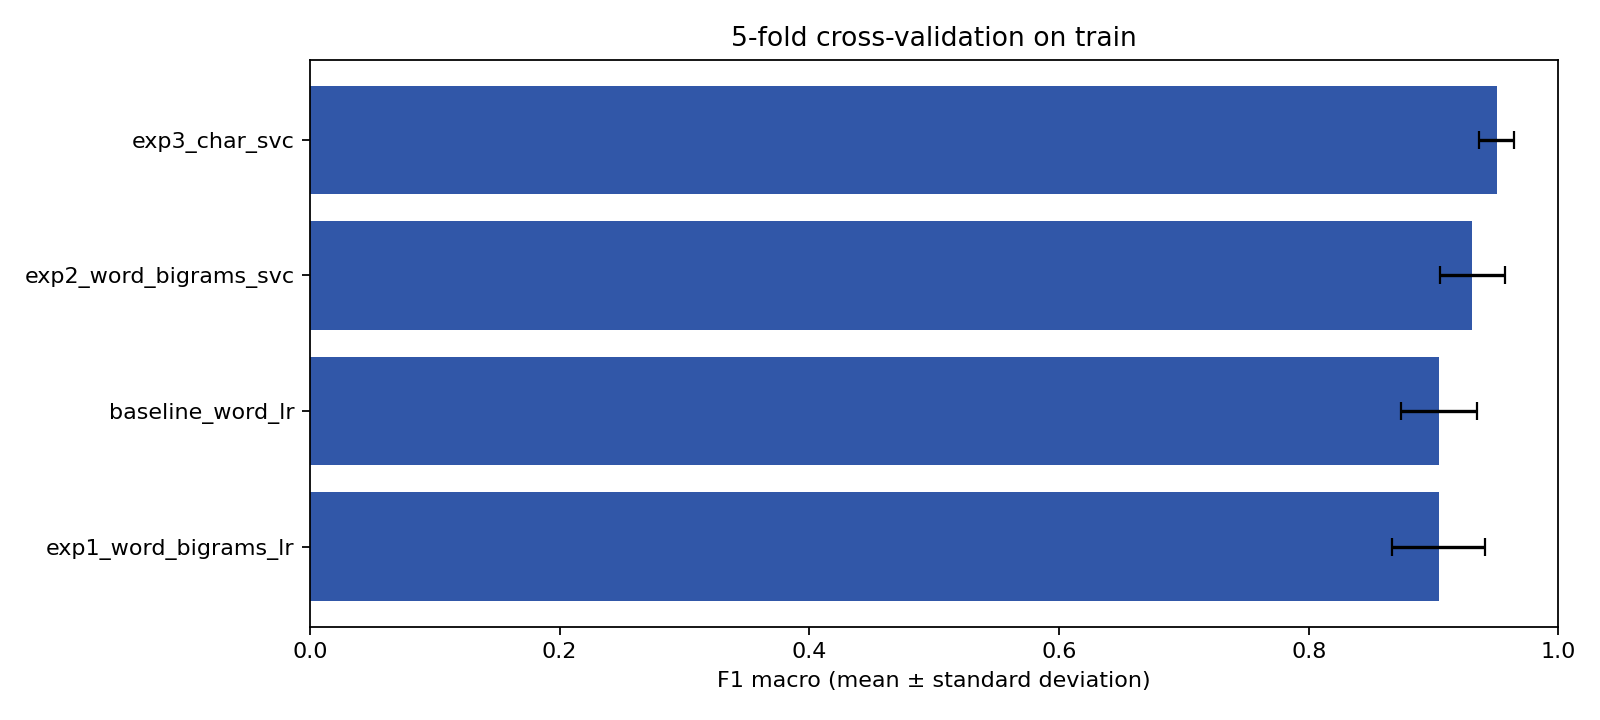

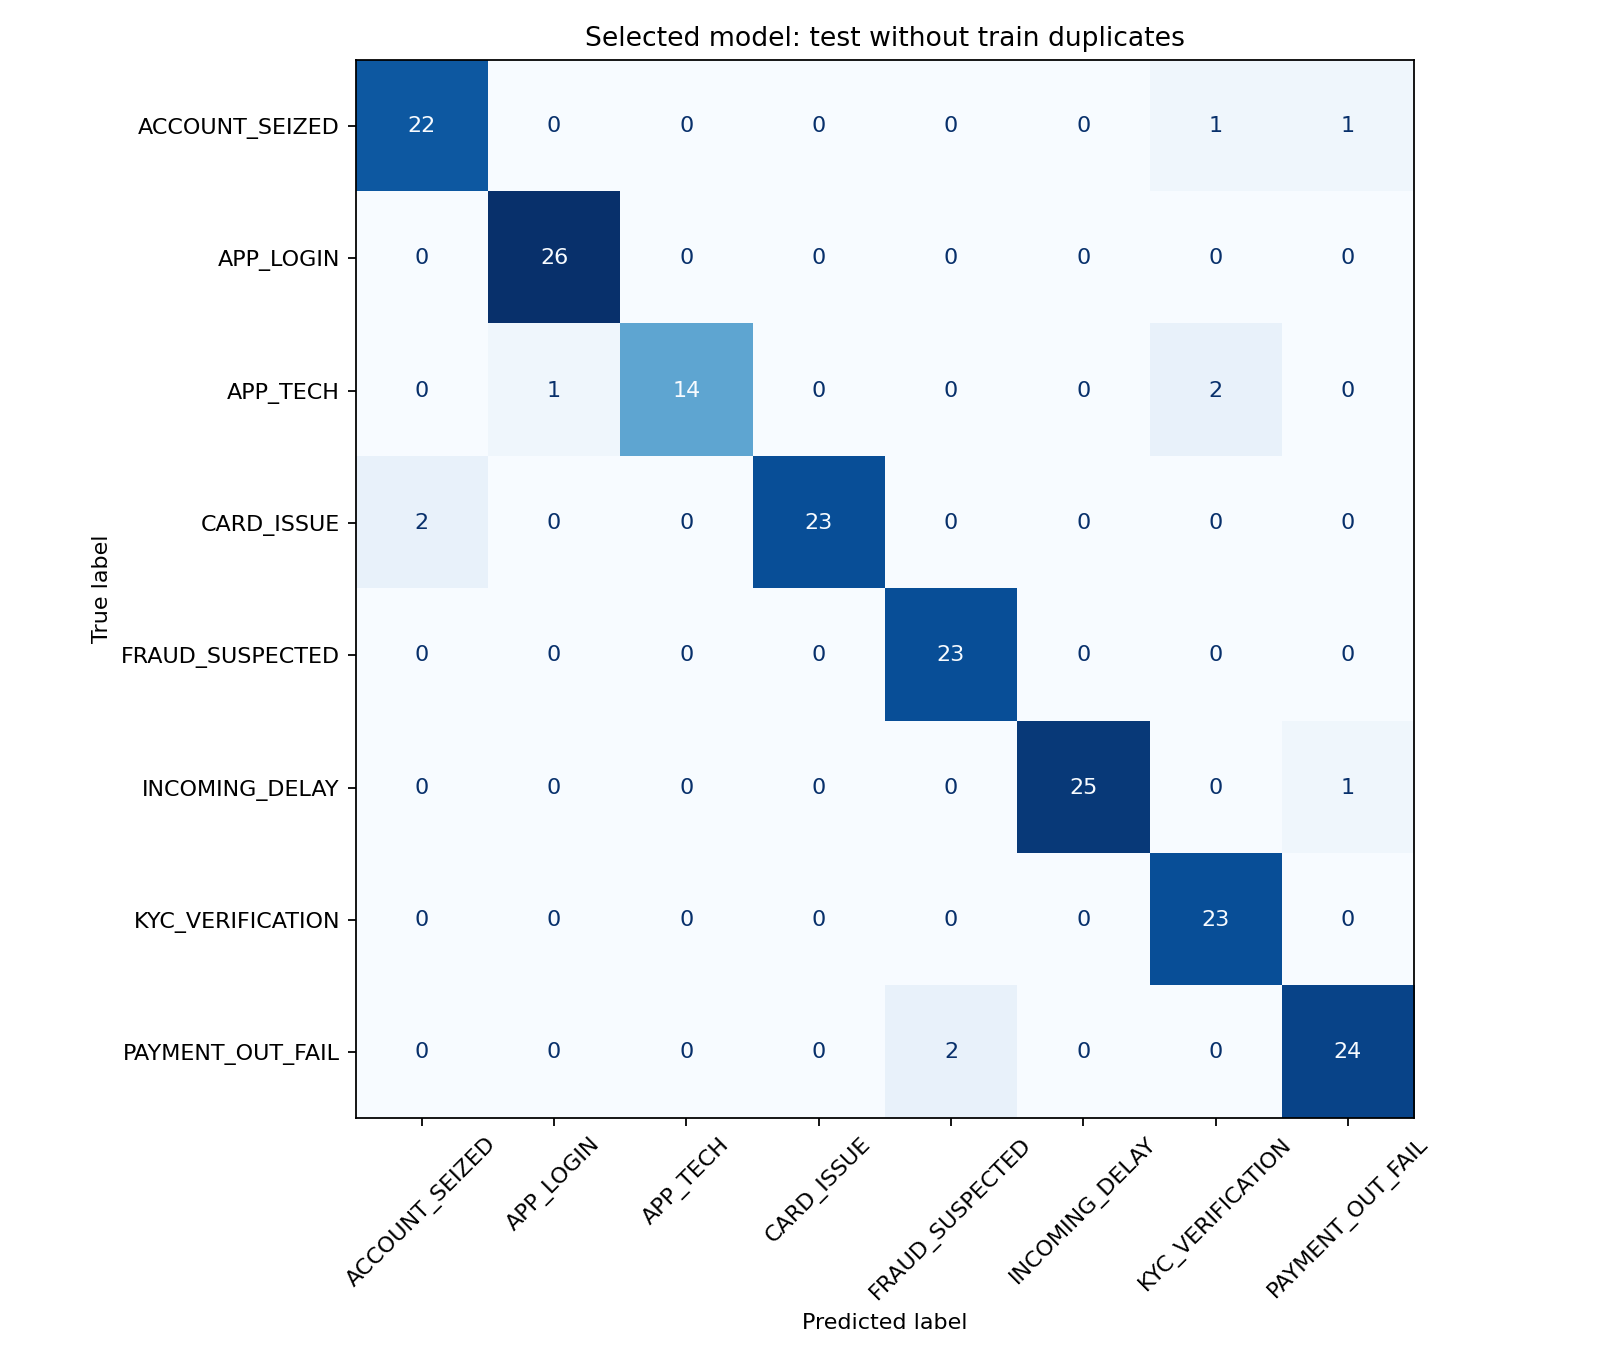

In [9]:
save_figures(results, matrix, sorted(model.classes_), REPORTS)
display(Image(filename=str(REPORTS / "cv_comparison.png")))
display(Image(filename=str(REPORTS / "confusion_matrix.png")))

### Вывод

Среди проверенных вариантов лучший результат показал `exp3_char_svc`: **F1-macro = 0.9505 ± 0.0138**. Он имеет как наибольшее среднее качество, так и наименьший разброс F1-macro между folds.
На test без совпадений с train модель правильно классифицировала **180 из 190 обращений**: **Accuracy = 94.74%**, **F1-macro = 0.9450**. Результат на test близок к среднему результату кросс-валидации (`0.9505`).
Для `APP_LOGIN`, `FRAUD_SUSPECTED` и `KYC_VERIFICATION` Recall равен **1.0** - все обращения этих классов были найдены. При этом существуют отдельные ложноположительные предсказания, поэтому Precision этих классов ниже 1.
Наиболее низкий Recall на test у `APP_TECH` - **0.8235**: 3 из 17 обращений этого класса были отнесены к другим категориям. В целом ошибки распределены между несколькими близкими по смыслу категориями.
Полученные результаты показывают хорошее качество на текущей тестовой выборке, однако из-за небольшого размера датасета и наличия похожих формулировок они не гарантируют такое же качество на новых реальных данных.

## 7. Сохранение и загрузка модели

Сохраняем:

- `bank_classifier.joblib` - весь Pipeline;
- `vectorizer.joblib` и `classifier.joblib` - отдельные компоненты;
- `metadata.json` - параметры, метрики и версии библиотек.

После загрузки проверяем, что сохранённые модели дают те же прогнозы на всех 191 строках `test`.

In [10]:
metadata = save_and_check(
    model, best_name, test, test_pred, audit, test_summary, ROOT
)
display(metadata["round_trip"])
for path in sorted((ROOT / "models").iterdir()):
    print(path.name, f"{path.stat().st_size / 1024:.1f} KiB")

Сохранение и обратная загрузка проверены на 191 обращениях: OK


{'pipeline': True, 'separate_components': True, 'rows_checked': 191}

bank_classifier.joblib 552.7 KiB
classifier.joblib 451.3 KiB
metadata.json 2.5 KiB
vectorizer.joblib 100.5 KiB


## 8. Использование сохранённой модели


In [11]:
loaded_model = joblib.load(ROOT / "models" / "bank_classifier.joblib")
new_texts = [
    "Не приходит СМС с кодом для входа в приложение",
    "Зарплата не пришла, хотя бухгалтерия уже отправила деньги",
    "Карта потерялась, хочу заблокировать её и заказать новую",
]
display(pd.DataFrame({
    "text": new_texts,
    "predicted_category": loaded_model.predict(new_texts),
}))

,text,predicted_category
0,Не приходит СМС с кодом для входа в приложение,APP_LOGIN
1,"Зарплата не пришла, хотя бухгалтерия уже отпра...",INCOMING_DELAY
2,"Карта потерялась, хочу заблокировать её и зака...",CARD_ISSUE


## 9. Сохранение итогового отчёта

In [12]:
write_report(
    results, best_name, test_summary, class_report, audit,
    oof, train, metadata, REPORTS
)

### Интерпретация результатов

Модель выбрана по общему протоколу кросс-валидации, а тестовая выборка использована только после выбора.

Датасет содержит похожие формулировки; найденные совпадения по регистру учтены, но все возможные шаблоны и перефразировки не сгруппированы.
Происхождение исходных обращений в просмотренных файлах не описано. Качество на реальных обращениях может отличаться.
Модель всегда выбирает одну из восьми категорий; неизвестные темы и маршрутизация в реальные банковские очереди здесь не реализованы.
